# Kitsune - Specialized Ensemble Transfer Evaluation

This notebook answers:

**How well does a model specialized for one attack transfer to other attacks, using an ensemble (RF + AE) instead of RF only?**

Approach summary:
1. Create one global train/test split on full Kitsune labels (0-4).
2. For each attack type, train a specialized ensemble using only `Normal (0)` vs that attack.
3. Evaluate each specialized ensemble on the same global test set containing all attack categories.
4. Report transfer detection rates for unseen attacks and false-positive rate on normal traffic.

In [ ]:
import sys
from pathlib import Path
from typing import Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Path setup
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

from src.autoencoder.autoencoder import Autoencoder
from src.ensemble.hybrid_ensemble import HybridIntrusionEnsemble

# Visual style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Runtime config
KITSUNE_PATH = project_root / 'data' / 'kitsune_2M.csv'
TEST_SIZE = 0.20
RANDOM_STATE = 42

AE_EPOCHS = 30
AE_BATCH_SIZE = 2048
AE_LATENT_DIM = 3

RF_TREES = 100
RF_WEIGHT = 0.7
AE_WEIGHT = 0.3
ENSEMBLE_THRESHOLD = 0.30

MAX_ROWS = None  # set an int for quick experiments (for example: 300000)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cpu


## 1. Load Data and Build a Global Split

The global split is shared by all specialized models so transfer comparisons are fair.

In [2]:
ATTACK_TYPES = {
    1: 'Reconnaissance',
    2: 'Man in the Middle',
    3: 'Denial of Service',
    4: 'Botnet Malware'
}

print('Loading Kitsune data...')
df = pd.read_csv(KITSUNE_PATH)
if MAX_ROWS is not None and MAX_ROWS < len(df):
    df = df.sample(n=MAX_ROWS, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f'Quick mode enabled with {len(df):,} sampled rows')

X_all = df.drop(columns=['category']).values
y_all = df['category'].values

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_all,
    y_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_all
)

print(f'Dataset shape: {df.shape}')
print(f'Train: {len(X_train_full):,}, Test: {len(X_test_full):,}')
print('Train class distribution:')
print(pd.Series(y_train_full).value_counts().sort_index())

Loading Kitsune data...
Dataset shape: (2000001, 116)
Train: 1,600,000, Test: 400,001
Train class distribution:
0    320004
1    320000
2    319998
3    319998
4    320000
Name: count, dtype: int64


## 2. Helper Functions

In [3]:
def train_autoencoder(
    X_normal_train: np.ndarray,
    input_dim: int,
    latent_dim: int = AE_LATENT_DIM,
    epochs: int = AE_EPOCHS,
    batch_size: int = AE_BATCH_SIZE,
) -> Autoencoder:
    model = Autoencoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.MSELoss()

    model.train()
    for epoch in range(1, epochs + 1):
        permutation = np.random.permutation(len(X_normal_train))
        epoch_loss = 0.0
        batches = 0

        for start in range(0, len(X_normal_train), batch_size):
            batch_idx = permutation[start:start + batch_size]
            batch = torch.from_numpy(X_normal_train[batch_idx]).float().to(device)

            optimizer.zero_grad()
            reconstruction = model(batch)
            loss = criterion(reconstruction, batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            batches += 1

        if epoch % 10 == 0 or epoch == epochs:
            print(f'    AE epoch {epoch:>3}/{epochs}, loss={epoch_loss / max(batches, 1):.6f}')

    model.eval()
    return model


def train_specialized_ensemble(
    X_train_global: np.ndarray,
    y_train_global: np.ndarray,
    attack_id: int,
    attack_name: str
) -> Dict[str, Any]:
    # Keep only Normal and one attack for specialization.
    mask = np.isin(y_train_global, [0, attack_id])
    X_spec_raw = X_train_global[mask]
    y_spec_multiclass = y_train_global[mask]
    y_spec_bin = (y_spec_multiclass == attack_id).astype(int)

    X_train_raw, X_val_raw, y_train_bin, y_val_bin = train_test_split(
        X_spec_raw,
        y_spec_bin,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_spec_bin
    )

    # Fit scaler only on normal samples from specialized train split.
    X_normal_train = X_train_raw[y_train_bin == 0]
    scaler = StandardScaler()
    scaler.fit(X_normal_train)

    X_train = scaler.transform(X_train_raw)
    X_val = scaler.transform(X_val_raw)

    rf = RandomForestClassifier(
        n_estimators=RF_TREES,
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    rf.fit(X_train, y_train_bin)

    ae_model = train_autoencoder(
        X_normal_train=scaler.transform(X_normal_train),
        input_dim=X_train.shape[1]
    )

    ensemble = HybridIntrusionEnsemble(
        rf_model=rf,
        ae_model=ae_model,
        rf_weight=RF_WEIGHT,
        ae_weight=AE_WEIGHT,
        threshold=ENSEMBLE_THRESHOLD,
        device=device
    )

    X_normal_val = X_val[y_val_bin == 0]
    ensemble.fit(X_normal_val)

    return {
        'attack_id': attack_id,
        'attack_name': attack_name,
        'scaler': scaler,
        'rf': rf,
        'ae': ae_model,
        'ensemble': ensemble,
        'train_count': len(X_train_raw),
        'val_count': len(X_val_raw)
    }

## 3. Train Specialized Ensemble Models

Each model is specialized to one binary task: `Normal vs one attack type`.

In [5]:
specialized_models: Dict[str, Dict[str, Any]] = {}

for attack_id, attack_name in ATTACK_TYPES.items():
    print('=' * 72)
    print(f'Training specialized ensemble: Normal vs {attack_name}')
    print('=' * 72)

    model_bundle = train_specialized_ensemble(
        X_train_global=X_train_full,
        y_train_global=y_train_full,
        attack_id=attack_id,
        attack_name=attack_name
    )

    specialized_models[attack_name] = model_bundle
    print(
        f"  samples used -> train: {model_bundle['train_count']:,}, val: {model_bundle['val_count']:,}"
    )

print(f'Trained specialized ensembles: {list(specialized_models.keys())}')

Training specialized ensemble: Normal vs Reconnaissance
    AE epoch  10/30, loss=0.037981
    AE epoch  20/30, loss=0.034704
    AE epoch  30/30, loss=0.030198
  samples used -> train: 512,003, val: 128,001
Training specialized ensemble: Normal vs Man in the Middle
    AE epoch  10/30, loss=0.042773
    AE epoch  20/30, loss=0.033722
    AE epoch  30/30, loss=0.030497
  samples used -> train: 512,001, val: 128,001
Training specialized ensemble: Normal vs Denial of Service
    AE epoch  10/30, loss=0.039926
    AE epoch  20/30, loss=0.036365
    AE epoch  30/30, loss=0.030523
  samples used -> train: 512,001, val: 128,001
Training specialized ensemble: Normal vs Botnet Malware
    AE epoch  10/30, loss=0.040713
    AE epoch  20/30, loss=0.034035
    AE epoch  30/30, loss=0.032363
  samples used -> train: 512,003, val: 128,001
Trained specialized ensembles: ['Reconnaissance', 'Man in the Middle', 'Denial of Service', 'Botnet Malware']


## 4. Cross-Attack Transfer Evaluation on the Global Test Set

For each specialized ensemble:
- evaluate on the same global test set,
- compute detection rate for each true attack type,
- compute normal false-positive rate (normal samples predicted as attack).

In [6]:
transfer_rows = []
confusion_tables = {}

for trained_on, bundle in specialized_models.items():
    scaler = bundle['scaler']
    ensemble = bundle['ensemble']

    X_test_scaled = scaler.transform(X_test_full)
    y_pred_bin = ensemble.predict(X_test_scaled).astype(int)

    normal_mask = (y_test_full == 0)
    normal_fpr = y_pred_bin[normal_mask].mean()

    for attack_id, attack_name in ATTACK_TYPES.items():
        attack_mask = (y_test_full == attack_id)
        detection_rate = y_pred_bin[attack_mask].mean()

        transfer_rows.append({
            'Trained On': trained_on,
            'Evaluated Attack': attack_name,
            'Detection Rate': detection_rate,
            'Normal FPR': normal_fpr
        })

    cm_table = pd.crosstab(
        pd.Series(y_test_full, name='True class'),
        pd.Series(y_pred_bin, name='Prediction'),
        rownames=['True class'],
        colnames=[f'Model decision (trained on {trained_on})']
    )
    confusion_tables[trained_on] = cm_table

transfer_df = pd.DataFrame(transfer_rows)
transfer_df.head()

,Trained On,Evaluated Attack,Detection Rate,Normal FPR
0,Reconnaissance,Reconnaissance,0.999988,0.010575
1,Reconnaissance,Man in the Middle,0.999637,0.010575
2,Reconnaissance,Denial of Service,0.998938,0.010575
3,Reconnaissance,Botnet Malware,0.890925,0.010575
4,Man in the Middle,Reconnaissance,0.999513,0.011087


In [7]:
detection_matrix = transfer_df.pivot(
    index='Trained On',
    columns='Evaluated Attack',
    values='Detection Rate'
)

normal_fpr_df = transfer_df[['Trained On', 'Normal FPR']].drop_duplicates().set_index('Trained On')

print('Detection rate matrix (specialized ensemble transfer):')
display(detection_matrix.style.format('{:.4f}'))

print('Normal false-positive rates:')
display(normal_fpr_df.style.format('{:.4f}'))

Detection rate matrix (specialized ensemble transfer):


Evaluated Attack,Botnet Malware,Denial of Service,Man in the Middle,Reconnaissance
Trained On,,,,
Botnet Malware,1.0000,0.9944,0.9995,0.9958
Denial of Service,0.9922,1.0000,0.9994,0.9991
Man in the Middle,0.9002,0.9992,1.0000,0.9995
Reconnaissance,0.8909,0.9989,0.9996,1.0000


Normal false-positive rates:


,Normal FPR
Trained On,
Reconnaissance,0.0106
Man in the Middle,0.0111
Denial of Service,0.0111
Botnet Malware,0.0112


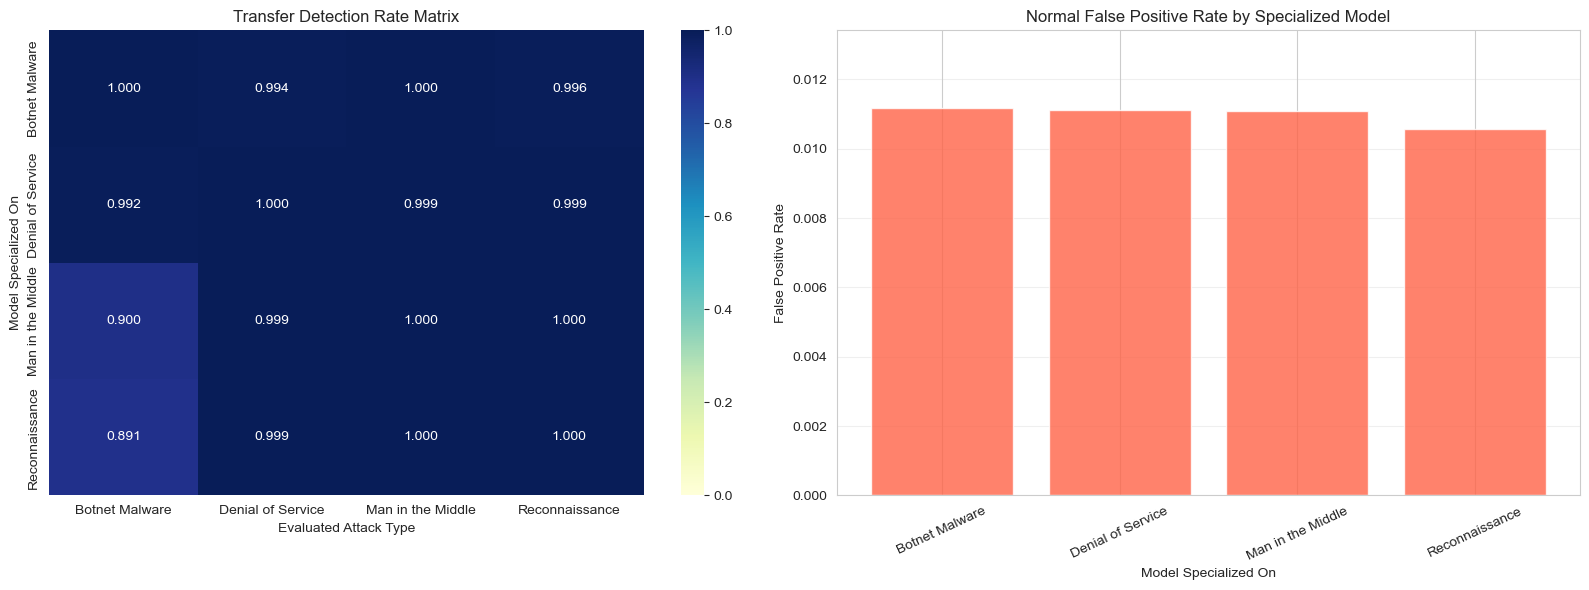

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    detection_matrix,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    vmin=0,
    vmax=1,
    ax=axes[0]
)
axes[0].set_title('Transfer Detection Rate Matrix')
axes[0].set_xlabel('Evaluated Attack Type')
axes[0].set_ylabel('Model Specialized On')

normal_fpr_df_sorted = normal_fpr_df.sort_values('Normal FPR', ascending=False)
axes[1].bar(normal_fpr_df_sorted.index, normal_fpr_df_sorted['Normal FPR'], color='tomato', alpha=0.8)
axes[1].set_title('Normal False Positive Rate by Specialized Model')
axes[1].set_ylabel('False Positive Rate')
axes[1].set_xlabel('Model Specialized On')
axes[1].set_ylim(0, min(1.0, normal_fpr_df_sorted['Normal FPR'].max() * 1.2 + 1e-6))
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Optional: inspect detailed confusion table for each specialized model
for trained_on, cm in confusion_tables.items():
    print('\n' + '=' * 72)
    print(f'Confusion-like table for model specialized on: {trained_on}')
    print('=' * 72)
    display(cm)


Confusion-like table for model specialized on: Reconnaissance


Model decision (trained on Reconnaissance),0,1
True class,,
0,79155,846
1,1,79999
2,29,79971
3,85,79915
4,8726,71274



Confusion-like table for model specialized on: Man in the Middle


Model decision (trained on Man in the Middle),0,1
True class,,
0,79114,887
1,39,79961
2,2,79998
3,61,79939
4,7987,72013



Confusion-like table for model specialized on: Denial of Service


Model decision (trained on Denial of Service),0,1
True class,,
0,79112,889
1,70,79930
2,49,79951
3,1,79999
4,620,79380



Confusion-like table for model specialized on: Botnet Malware


Model decision (trained on Botnet Malware),0,1
True class,,
0,79107,894
1,339,79661
2,40,79960
3,445,79555
4,0,80000


## 5. Notes

- High diagonal values in the detection matrix indicate strong in-domain performance.
- Off-diagonal values measure transfer to unseen attack types.
- Compare transfer gains against the RF-only notebook to quantify the value of adding AE into the ensemble.
- If runtime is high, set `MAX_ROWS` to a smaller value for rapid iteration.